<a href="https://colab.research.google.com/github/Rohan-1810/Models-of-major-project/blob/main/U-Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount("/content/drive")

# Persistent project directory
PROJECT_DIR = Path(
    "/content/drive/MyDrive/LungSegmentation"
)

# Create folders
DATASET_DIR = PROJECT_DIR / "dataset"
MODEL_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"

DATASET_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Google Drive mounted successfully!")
print("Project directory:", PROJECT_DIR)
print("Dataset directory :", DATASET_DIR)
print("Model directory   :", MODEL_DIR)
print("Results directory :", RESULTS_DIR)

Mounted at /content/drive
Google Drive mounted successfully!
Project directory: /content/drive/MyDrive/LungSegmentation
Dataset directory : /content/drive/MyDrive/LungSegmentation/dataset
Model directory   : /content/drive/MyDrive/LungSegmentation/models
Results directory : /content/drive/MyDrive/LungSegmentation/results


Defining the Dataset Location

In [ ]:
print("Project folder exists :", PROJECT_DIR.exists())
print("Dataset folder exists :", DATASET_DIR.exists())
print("Models folder exists  :", MODEL_DIR.exists())
print("Results folder exists :", RESULTS_DIR.exists())

print("\nProject contents:")
for item in PROJECT_DIR.iterdir():
    print(" -", item.name)

Project folder exists : True
Dataset folder exists : True
Models folder exists  : True
Results folder exists : True

Project contents:
 - dataset
 - models
 - results


In [ ]:
# Persistent location for the Montgomery dataset
MONTGOMERY_DIR = DATASET_DIR / "MontgomerySet"

# Expected subfolders
IMAGE_DIR = MONTGOMERY_DIR / "CXR_png"
LEFT_MASK_DIR = MONTGOMERY_DIR / "ManualMask" / "leftMask"
RIGHT_MASK_DIR = MONTGOMERY_DIR / "ManualMask" / "rightMask"

print("Montgomery dataset location:")
print(MONTGOMERY_DIR)

print("\nExpected structure:")
print(MONTGOMERY_DIR / "CXR_png")
print(MONTGOMERY_DIR / "ManualMask" / "leftMask")
print(MONTGOMERY_DIR / "ManualMask" / "rightMask")

Montgomery dataset location:
/content/drive/MyDrive/LungSegmentation/dataset/MontgomerySet

Expected structure:
/content/drive/MyDrive/LungSegmentation/dataset/MontgomerySet/CXR_png
/content/drive/MyDrive/LungSegmentation/dataset/MontgomerySet/ManualMask/leftMask
/content/drive/MyDrive/LungSegmentation/dataset/MontgomerySet/ManualMask/rightMask


Download the Montgomery Dataset

In [ ]:
from huggingface_hub import snapshot_download

print("Downloading Montgomery dataset...")
print("Destination:", MONTGOMERY_DIR)

snapshot_download(
    repo_id="Famatsu123/montgomery-shenzhen-tuberculosis-cxr",
    repo_type="dataset",
    local_dir=str(DATASET_DIR),
    allow_patterns=[
        "MontgomerySet/CXR_png/*.png",
        "MontgomerySet/ManualMask/leftMask/*.png",
        "MontgomerySet/ManualMask/rightMask/*.png"
    ]
)

print("\nDataset download completed!")

Destination: /content/drive/MyDrive/LungSegmentation/dataset/MontgomerySet


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 414 files:   0%|          | 0/414 [00:00<?, ?it/s]


Dataset download completed!


Verify the Dataset

In [ ]:
# Find all PNG images
image_files = sorted(IMAGE_DIR.glob("*.png"))

# Keep only images with both masks
valid_images = [
    img for img in image_files
    if (LEFT_MASK_DIR / img.name).exists()
    and (RIGHT_MASK_DIR / img.name).exists()
]

print("Total PNG images :", len(image_files))
print("Valid image pairs:", len(valid_images))

# Show a sample
if len(valid_images) > 0:
    sample = valid_images[0]

    print("\nExample:")
    print("Image      :", sample.name)
    print(
        "Left mask  :",
        (LEFT_MASK_DIR / sample.name).exists()
    )
    print(
        "Right mask :",
        (RIGHT_MASK_DIR / sample.name).exists()
    )

Total PNG images : 138
Valid image pairs: 138

Example:
Image      : MCUCXR_0001_0.png
Left mask  : True
Right mask : True


Import Libraries + Set Device

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from PIL import Image
from pathlib import Path

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using: cuda
GPU: Tesla T4


Create U-Net

In [ ]:
class DoubleConv(nn.Module):
    """(Conv => BN => ReLU) * 2"""

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class Down(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Same as bilinear=True in the repository
        self.up = nn.UpsamplingBilinear2d(
            scale_factor=2
        )

        self.conv = DoubleConv(
            in_channels,
            out_channels
        )

    def forward(self, x1, x2):

        x1 = self.up(x1)

        # Handle possible size differences
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2
            ]
        )

        # Skip connection
        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


class OutConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self, n_channels=3, n_classes=1):
        super().__init__()

        # Encoder
        self.inc = DoubleConv(n_channels, 64)

        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 512)

        # Decoder
        self.up1 = Up(1024, 256)
        self.up2 = Up(512, 128)
        self.up3 = Up(256, 64)
        self.up4 = Up(128, 64)

        # Output
        self.outc = OutConv(64, n_classes)

        # Same dropout as repository
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):

        x1 = self.inc(x)

        x2 = self.down1(x1)

        x3 = self.down2(x2)
        x3 = self.dropout(x3)

        x4 = self.down3(x3)

        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)

        return logits


# Create model
model = UNet(
    n_channels=3,
    n_classes=1
).to(device)

print("U-Net created successfully!")
print("Parameters:", sum(p.numel() for p in model.parameters()))

U-Net created successfully!
Parameters: 13395329


Verify U-Net Input and Output

In [ ]:
# Dummy chest X-ray
dummy_input = torch.randn(
    1, 3, 512, 512,
    device=device
)

# Forward pass
with torch.no_grad():
    dummy_output = model(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", dummy_output.shape)

if torch.cuda.is_available():
    print(
        "GPU memory allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

Input shape : torch.Size([1, 3, 512, 512])
Output shape: torch.Size([1, 1, 512, 512])
GPU memory allocated: 0.05 GB


Create the Dataset Class

In [ ]:
class LungDataset(Dataset):

    def __init__(
        self,
        image_dir,
        left_mask_dir,
        right_mask_dir
    ):
        self.image_dir = Path(image_dir)
        self.left_mask_dir = Path(left_mask_dir)
        self.right_mask_dir = Path(right_mask_dir)

        # Get all valid X-rays
        self.images = sorted(
            self.image_dir.glob("*.png")
        )

        # Keep only images having both masks
        self.images = [
            img for img in self.images
            if (
                self.left_mask_dir / img.name
            ).exists()
            and (
                self.right_mask_dir / img.name
            ).exists()
        ]

        # Image preprocessing
        self.image_transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor()
        ])

        # Mask preprocessing
        # NEAREST preserves binary labels
        self.mask_resize = transforms.Resize(
            (512, 512),
            interpolation=transforms.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        # -------------------------
        # Load X-ray
        # -------------------------
        image_path = self.images[idx]

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.image_transform(image)

        # -------------------------
        # Load left + right masks
        # -------------------------
        left_path = (
            self.left_mask_dir / image_path.name
        )

        right_path = (
            self.right_mask_dir / image_path.name
        )

        left_mask = Image.open(
            left_path
        ).convert("L")

        right_mask = Image.open(
            right_path
        ).convert("L")

        # Resize masks
        left_mask = self.mask_resize(left_mask)
        right_mask = self.mask_resize(right_mask)

        # Convert to NumPy
        left_mask = np.array(left_mask)
        right_mask = np.array(right_mask)

        # Combine both lungs
        combined_mask = np.maximum(
            left_mask,
            right_mask
        )

        # Convert to binary
        combined_mask = (
            combined_mask > 0
        ).astype(np.float32)

        # Convert to tensor
        combined_mask = torch.tensor(
            combined_mask,
            dtype=torch.float32
        )

        # Add channel dimension
        # [512, 512] → [1, 512, 512]
        combined_mask = combined_mask.unsqueeze(0)

        return image, combined_mask


# Create dataset
dataset = LungDataset(
    IMAGE_DIR,
    LEFT_MASK_DIR,
    RIGHT_MASK_DIR
)

print("Dataset created successfully!")
print("Number of samples:", len(dataset))

Dataset created successfully!
Number of samples: 138


Check One Real Image + Mask

In [ ]:
# Get one sample
image, mask = dataset[0]

print("Image shape :", image.shape)
print("Mask shape  :", mask.shape)

print("Image dtype :", image.dtype)
print("Mask dtype  :", mask.dtype)

print("Image range :", image.min().item(), "to", image.max().item())
print("Mask values :", torch.unique(mask))

# Check dimensions
assert image.shape == (3, 512, 512)
assert mask.shape == (1, 512, 512)

print("\nDataset sample is valid!")

Image shape : torch.Size([3, 512, 512])
Mask shape  : torch.Size([1, 512, 512])
Image dtype : torch.float32
Mask dtype  : torch.float32
Image range : 0.0 to 1.0
Mask values : tensor([0., 1.])

Dataset sample is valid!


# **Train / Validation / Test Split + DataLoaders**

We'll use 80% train, 10% validation, 10% test.

With 138 images, that's approximately:

110 → training
13 → validation
15 → final test

In [ ]:
# -------------------------
# Reproducible split
# -------------------------

torch.manual_seed(42)

total_size = len(dataset)

train_size = int(0.80 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Total samples :", total_size)
print("Training      :", len(train_dataset))
print("Validation    :", len(val_dataset))
print("Testing       :", len(test_dataset))


# -------------------------
# DataLoaders
# -------------------------

BATCH_SIZE = 1

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataLoaders created successfully!")

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Total samples : 138
Training      : 110
Validation    : 13
Testing       : 15

DataLoaders created successfully!
Train batches: 110
Val batches  : 13
Test batches : 15


Test the DataLoader

In [ ]:
# Get one batch from the training DataLoader
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape :", masks.shape)

# Move batch to GPU
images = images.to(device)
masks = masks.to(device)

# Pass through U-Net
with torch.no_grad():
    predictions = model(images)

print("Predictions shape:", predictions.shape)

# Check GPU memory
if torch.cuda.is_available():
    print(
        "GPU memory allocated:",
        round(torch.cuda.memory_allocated() / 1024**3, 2),
        "GB"
    )

# Verify shapes
assert images.shape == (1, 3, 512, 512)
assert masks.shape == (1, 1, 512, 512)
assert predictions.shape == (1, 1, 512, 512)

print("\nDataLoader → U-Net test PASSED!")

Images shape: torch.Size([1, 3, 512, 512])
Masks shape : torch.Size([1, 1, 512, 512])
Predictions shape: torch.Size([1, 1, 512, 512])
GPU memory allocated: 0.06 GB

DataLoader → U-Net test PASSED!


Loss Functions + Optimizer

In [ ]:
# =========================
# Dice Loss
# =========================

class SoftDiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):

        # Convert logits to probabilities
        predictions = torch.sigmoid(predictions)

        # Flatten
        predictions = predictions.contiguous().view(-1)
        targets = targets.contiguous().view(-1)

        # Intersection
        intersection = (predictions * targets).sum()

        # Dice coefficient
        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                predictions.sum()
                + targets.sum()
                + self.smooth
            )
        )

        return 1.0 - dice


# =========================
# Inverse Soft Dice Loss
# =========================

class InvSoftDiceLoss(nn.Module):

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):

        # Convert logits to probabilities
        predictions = torch.sigmoid(predictions)

        # Flatten
        predictions = predictions.contiguous().view(-1)
        targets = targets.contiguous().view(-1)

        intersection = (predictions * targets).sum()

        dice = (
            (2.0 * intersection + self.smooth)
            /
            (
                predictions.sum()
                + targets.sum()
                + self.smooth
            )
        )

        # Inverse Dice
        return 1.0 / (dice + self.smooth)


# =========================
# Loss functions
# =========================

criterion1 = nn.BCEWithLogitsLoss()
criterion2 = SoftDiceLoss()
criterion3 = InvSoftDiceLoss()


# =========================
# Optimizer
# =========================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


print("Loss functions created:")
print("1. BCEWithLogitsLoss")
print("2. SoftDiceLoss")
print("3. InvSoftDiceLoss")

print("\nOptimizer:")
print("Adam")
print("Learning rate:", 1e-4)

Loss functions created:
1. BCEWithLogitsLoss
2. SoftDiceLoss
3. InvSoftDiceLoss

Optimizer:
Adam
Learning rate: 0.0001


Test the Loss Functions

In [ ]:
# Get one real training batch
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

# Forward pass
predictions = model(images)

# Calculate individual losses
bce_loss = criterion1(predictions, masks)
dice_loss = criterion2(predictions, masks)
inv_dice_loss = criterion3(predictions, masks)

# Total loss
total_loss = bce_loss + dice_loss + inv_dice_loss

print("BCE Loss       :", bce_loss.item())
print("Soft Dice Loss :", dice_loss.item())
print("Inverse Dice   :", inv_dice_loss.item())
print("Total Loss     :", total_loss.item())

# Check that everything is valid
assert torch.isfinite(total_loss), "Loss contains NaN or Inf!"

print("\nLoss test PASSED!")

BCE Loss       : 0.6620040535926819
Soft Dice Loss : 0.6706818342208862
Inverse Dice   : 0.7522653341293335
Total Loss     : 2.084951400756836

Loss test PASSED!


Training Loop

In [ ]:
# =========================
# Training Configuration
# =========================

NUM_EPOCHS = 20

BEST_MODEL_PATH = MODEL_DIR / "unet_best.pth"
LATEST_MODEL_PATH = MODEL_DIR / "unet_latest.pth"
HISTORY_PATH = RESULTS_DIR / "training_history.pt"

best_val_loss = float("inf")

train_losses = []
val_losses = []


# =========================
# Training Loop
# =========================

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(images)

        # Individual losses
        loss_bce = criterion1(predictions, masks)
        loss_dice = criterion2(predictions, masks)
        loss_inv_dice = criterion3(predictions, masks)

        # Total loss
        loss = (
            loss_bce
            + loss_dice
            + loss_inv_dice
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = (
        running_train_loss / len(train_loader)
    )


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            predictions = model(images)

            loss_bce = criterion1(predictions, masks)
            loss_dice = criterion2(predictions, masks)
            loss_inv_dice = criterion3(predictions, masks)

            loss = (
                loss_bce
                + loss_dice
                + loss_inv_dice
            )

            running_val_loss += loss.item()

    epoch_val_loss = (
        running_val_loss / len(val_loader)
    )


    # -------------------------
    # Store history
    # -------------------------
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)


    # -------------------------
    # Save latest checkpoint
    # -------------------------
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": epoch_train_loss,
        "val_loss": epoch_val_loss,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

    torch.save(
        checkpoint,
        LATEST_MODEL_PATH
    )


    # -------------------------
    # Save best model
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        best_marker = "  <-- BEST"

    else:
        best_marker = ""


    # -------------------------
    # Print progress
    # -------------------------
    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
        f"{best_marker}"
    )


# =========================
# Save training history
# =========================

torch.save(
    {
        "train_losses": train_losses,
        "val_losses": val_losses
    },
    HISTORY_PATH
)

print("\nTraining completed!")

print("Best validation loss:", round(best_val_loss, 4))

print("\nSaved to Google Drive:")
print("Best model :", BEST_MODEL_PATH)
print("Latest     :", LATEST_MODEL_PATH)
print("History    :", HISTORY_PATH)

Epoch [01/20] Train Loss: 1.2387 | Val Loss: 1.2743  <-- BEST
Epoch [02/20] Train Loss: 0.9620 | Val Loss: 0.9305  <-- BEST
Epoch [03/20] Train Loss: 0.8634 | Val Loss: 0.8367  <-- BEST
Epoch [04/20] Train Loss: 0.8292 | Val Loss: 0.8248  <-- BEST
Epoch [05/20] Train Loss: 0.7759 | Val Loss: 0.8015  <-- BEST
Epoch [06/20] Train Loss: 0.7225 | Val Loss: 0.7498  <-- BEST
Epoch [07/20] Train Loss: 0.6903 | Val Loss: 0.7024  <-- BEST
Epoch [08/20] Train Loss: 0.6602 | Val Loss: 0.6893  <-- BEST
Epoch [09/20] Train Loss: 0.6432 | Val Loss: 0.6924
Epoch [10/20] Train Loss: 0.6376 | Val Loss: 0.6731  <-- BEST
Epoch [11/20] Train Loss: 0.6575 | Val Loss: 0.6717  <-- BEST
Epoch [12/20] Train Loss: 0.6163 | Val Loss: 0.6563  <-- BEST
Epoch [13/20] Train Loss: 0.6019 | Val Loss: 0.6403  <-- BEST
Epoch [14/20] Train Loss: 0.5969 | Val Loss: 0.6551
Epoch [15/20] Train Loss: 0.5904 | Val Loss: 0.6380  <-- BEST
Epoch [16/20] Train Loss: 0.5868 | Val Loss: 0.6543
Epoch [17/20] Train Loss: 0.5815 | Val

Load Best Model + Evaluate on Test Set

In [ ]:
# =========================
# Load Best Checkpoint
# =========================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("Best model loaded successfully!")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])


# =========================
# Evaluation Metrics
# =========================

def calculate_dice(predictions, targets, threshold=0.5, smooth=1e-6):

    probabilities = torch.sigmoid(predictions)

    predicted_mask = (
        probabilities > threshold
    ).float()

    intersection = (
        predicted_mask * targets
    ).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        predicted_mask.sum()
        + targets.sum()
        + smooth
    )

    return dice.item()


def calculate_iou(predictions, targets, threshold=0.5, smooth=1e-6):

    probabilities = torch.sigmoid(predictions)

    predicted_mask = (
        probabilities > threshold
    ).float()

    intersection = (
        predicted_mask * targets
    ).sum()

    union = (
        predicted_mask
        + targets
        - predicted_mask * targets
    ).sum()

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou.item()


# =========================
# Test Evaluation
# =========================

test_dice_scores = []
test_iou_scores = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        predictions = model(images)

        dice = calculate_dice(
            predictions,
            masks
        )

        iou = calculate_iou(
            predictions,
            masks
        )

        test_dice_scores.append(dice)
        test_iou_scores.append(iou)


# =========================
# Final Results
# =========================

mean_dice = np.mean(test_dice_scores)
mean_iou = np.mean(test_iou_scores)

print("\n" + "=" * 40)
print("FINAL TEST RESULTS")
print("=" * 40)

print(f"Test images : {len(test_dataset)}")
print(f"Mean Dice   : {mean_dice:.4f}")
print(f"Mean IoU    : {mean_iou:.4f}")

print("=" * 40)

Best model loaded successfully!
Best epoch: 17
Best validation loss: 0.6252158421736497

FINAL TEST RESULTS
Test images : 15
Mean Dice   : 0.9758
Mean IoU    : 0.9532


# Visualize Predictions on Test Images

This displays 4 things for several test images:

Original X-ray
Ground-truth mask
Predicted mask
Overlay of prediction on the X-ray

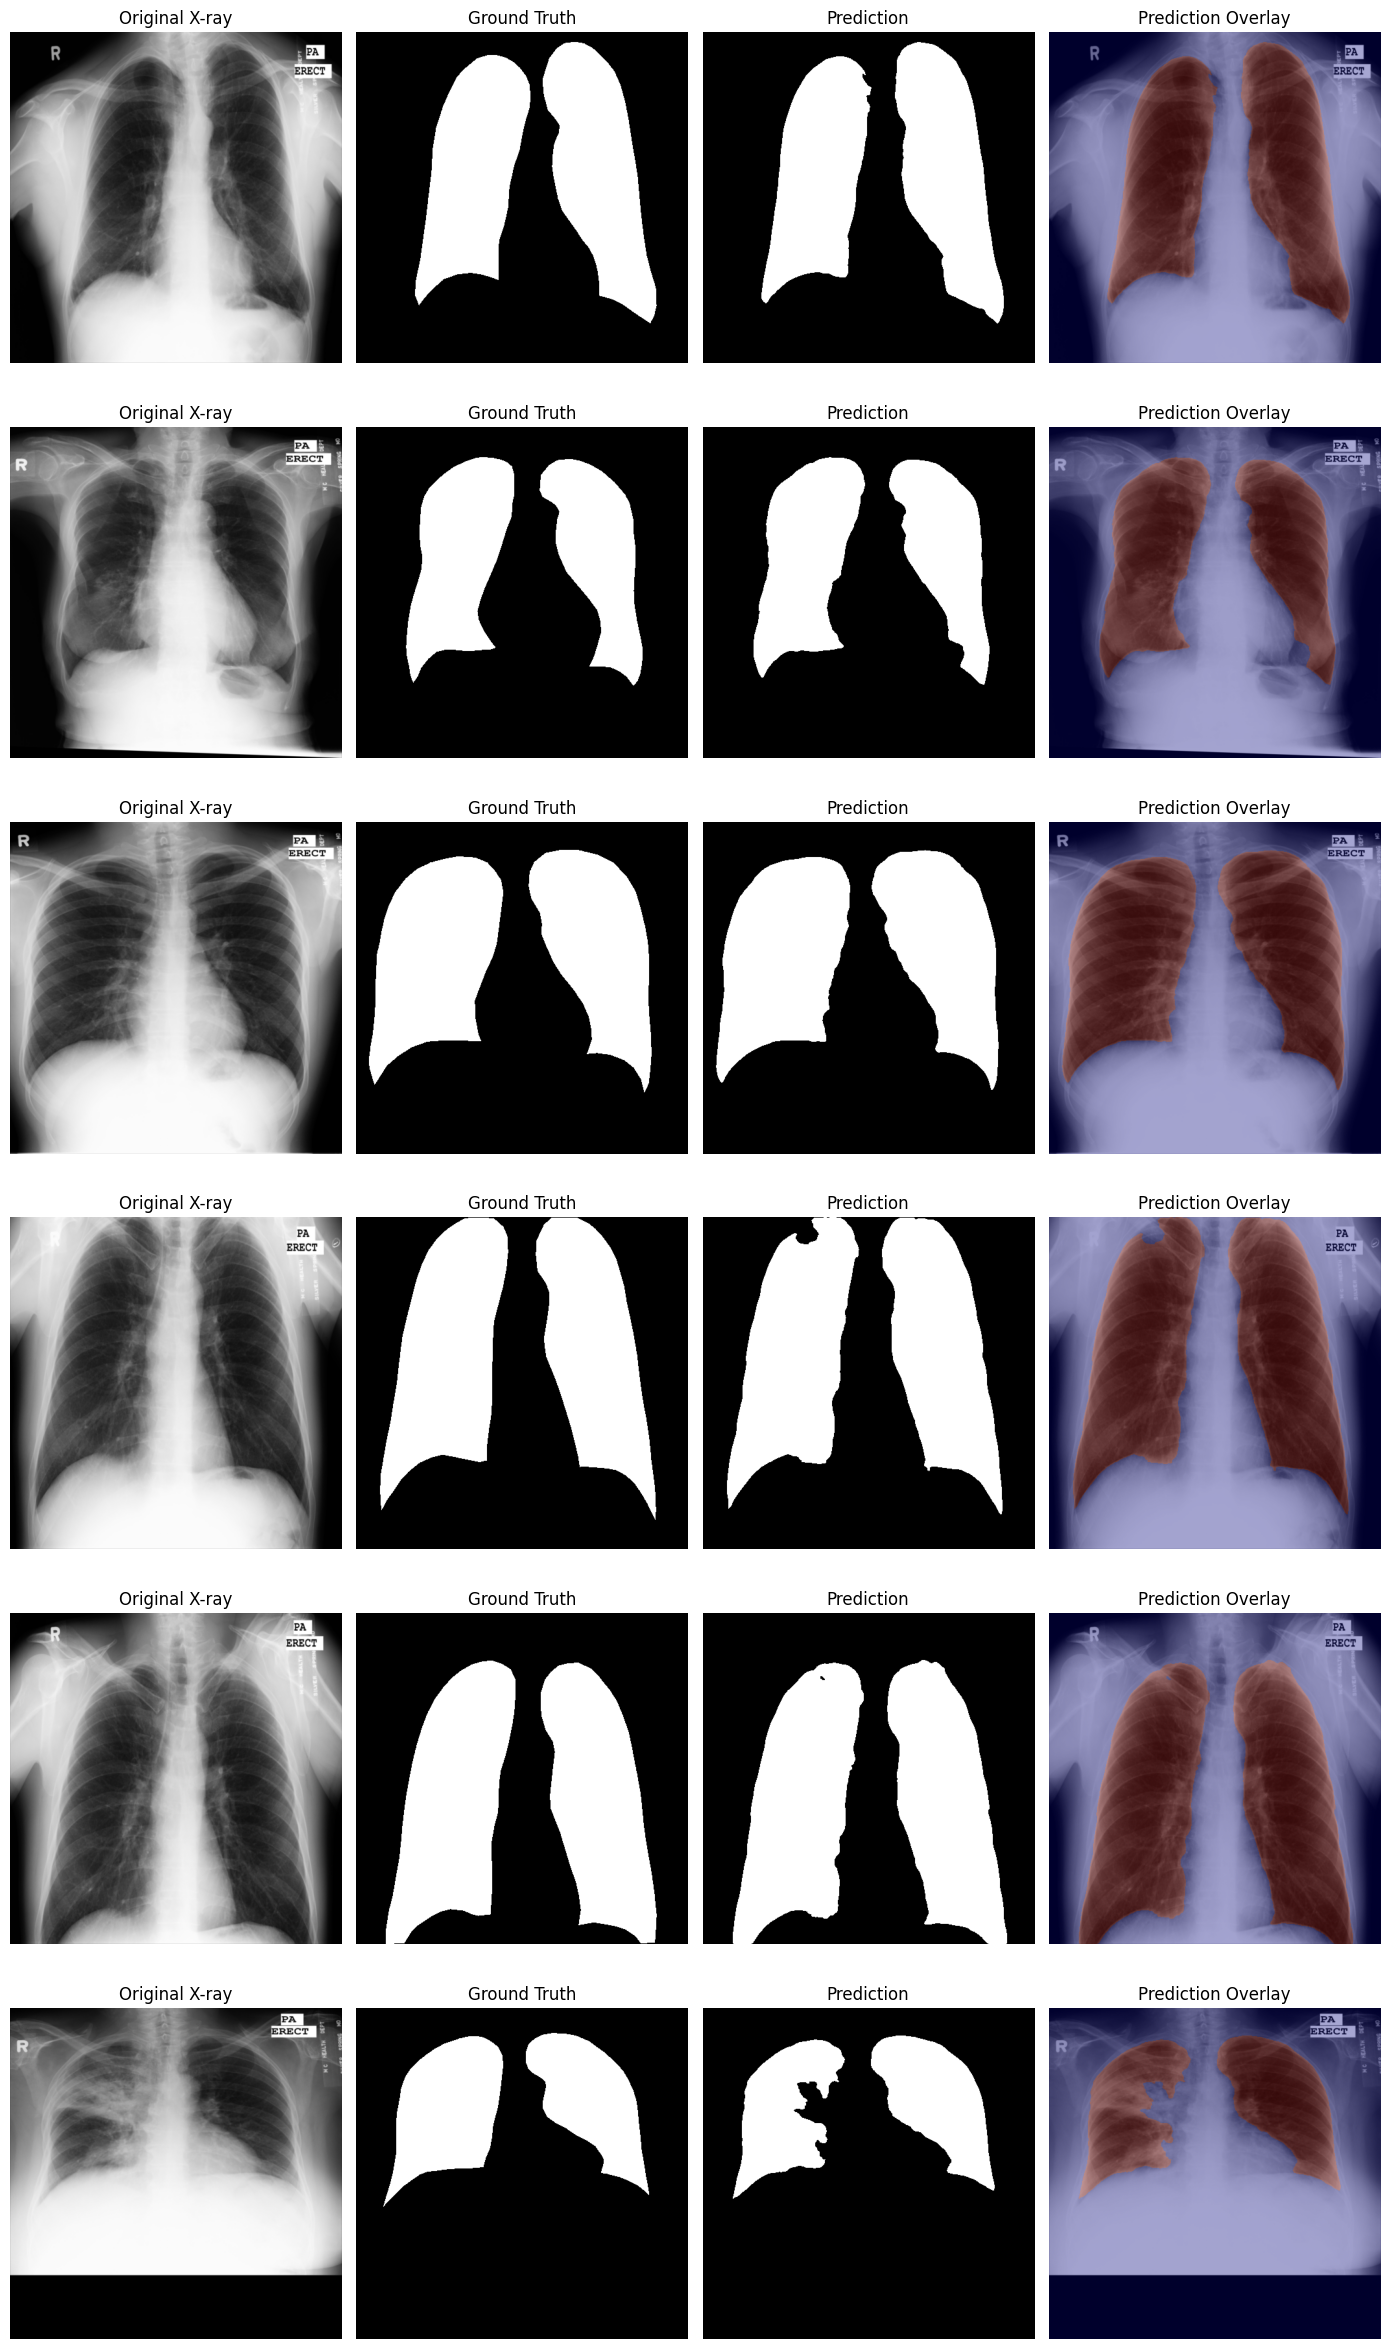

In [ ]:
import matplotlib.pyplot as plt

# Number of test images to visualize
NUM_SAMPLES = min(6, len(test_dataset))

model.eval()

fig, axes = plt.subplots(
    NUM_SAMPLES,
    4,
    figsize=(14, 4 * NUM_SAMPLES)
)

# Handle the case of only one sample
if NUM_SAMPLES == 1:
    axes = np.expand_dims(axes, axis=0)

with torch.no_grad():

    for i in range(NUM_SAMPLES):

        # Get test sample
        image, mask = test_dataset[i]

        # Add batch dimension and move to GPU
        input_image = image.unsqueeze(0).to(device)

        # Prediction
        logits = model(input_image)

        probability = torch.sigmoid(logits)

        predicted_mask = (
            probability > 0.5
        ).float()

        # Convert to NumPy for visualization
        image_np = image.permute(1, 2, 0).cpu().numpy()

        ground_truth_np = (
            mask.squeeze(0).cpu().numpy()
        )

        predicted_np = (
            predicted_mask.squeeze()
            .cpu()
            .numpy()
        )

        # -------------------------
        # Original X-ray
        # -------------------------
        axes[i, 0].imshow(
            image_np,
            cmap="gray"
        )
        axes[i, 0].set_title("Original X-ray")
        axes[i, 0].axis("off")

        # -------------------------
        # Ground truth
        # -------------------------
        axes[i, 1].imshow(
            ground_truth_np,
            cmap="gray"
        )
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        # -------------------------
        # Prediction
        # -------------------------
        axes[i, 2].imshow(
            predicted_np,
            cmap="gray"
        )
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

        # -------------------------
        # Overlay
        # -------------------------
        axes[i, 3].imshow(
            image_np,
            cmap="gray"
        )

        axes[i, 3].imshow(
            predicted_np,
            alpha=0.35,
            cmap="jet"
        )

        axes[i, 3].set_title("Prediction Overlay")
        axes[i, 3].axis("off")


plt.tight_layout()
plt.show()

Per-image Test Metrics

In [ ]:
# =========================
# Per-image Test Evaluation
# =========================

model.eval()

per_image_results = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        image, mask = test_dataset[i]

        image_input = image.unsqueeze(0).to(device)
        mask_input = mask.unsqueeze(0).to(device)

        # Prediction
        logits = model(image_input)

        # Metrics
        dice = calculate_dice(
            logits,
            mask_input
        )

        iou = calculate_iou(
            logits,
            mask_input
        )

        # Get original filename
        dataset_index = test_dataset.indices[i]
        filename = dataset.images[dataset_index].name

        per_image_results.append({
            "index": i,
            "filename": filename,
            "dice": dice,
            "iou": iou
        })


# Sort by Dice score
per_image_results = sorted(
    per_image_results,
    key=lambda x: x["dice"],
    reverse=True
)


# =========================
# Print Results
# =========================

print("=" * 65)
print("PER-IMAGE TEST RESULTS")
print("=" * 65)

print(
    f"{'Rank':<6}"
    f"{'Filename':<22}"
    f"{'Dice':<12}"
    f"{'IoU':<12}"
)

print("-" * 65)

for rank, result in enumerate(
    per_image_results,
    start=1
):

    print(
        f"{rank:<6}"
        f"{result['filename']:<22}"
        f"{result['dice']:<12.4f}"
        f"{result['iou']:<12.4f}"
    )


# =========================
# Best / Worst
# =========================

best_case = per_image_results[0]
worst_case = per_image_results[-1]

print("\n" + "=" * 65)

print("BEST CASE")
print("Filename:", best_case["filename"])
print("Dice    :", round(best_case["dice"], 4))
print("IoU     :", round(best_case["iou"], 4))

print("\nWORST CASE")
print("Filename:", worst_case["filename"])
print("Dice    :", round(worst_case["dice"], 4))
print("IoU     :", round(worst_case["iou"], 4))

print("=" * 65)

PER-IMAGE TEST RESULTS
Rank  Filename              Dice        IoU         
-----------------------------------------------------------------
1     MCUCXR_0051_0.png     0.9856      0.9717      
2     MCUCXR_0022_0.png     0.9850      0.9705      
3     MCUCXR_0001_0.png     0.9846      0.9697      
4     MCUCXR_0162_1.png     0.9827      0.9659      
5     MCUCXR_0042_0.png     0.9823      0.9653      
6     MCUCXR_0028_0.png     0.9818      0.9643      
7     MCUCXR_0023_0.png     0.9805      0.9617      
8     MCUCXR_0059_0.png     0.9803      0.9614      
9     MCUCXR_0082_0.png     0.9802      0.9612      
10    MCUCXR_0083_0.png     0.9771      0.9553      
11    MCUCXR_0058_0.png     0.9752      0.9516      
12    MCUCXR_0080_0.png     0.9752      0.9515      
13    MCUCXR_0002_0.png     0.9746      0.9504      
14    MCUCXR_0213_1.png     0.9737      0.9487      
15    MCUCXR_0399_1.png     0.9180      0.8484      

BEST CASE
Filename: MCUCXR_0051_0.png
Dice    : 0.9856
IoU    

Visualize the Worst Test Case

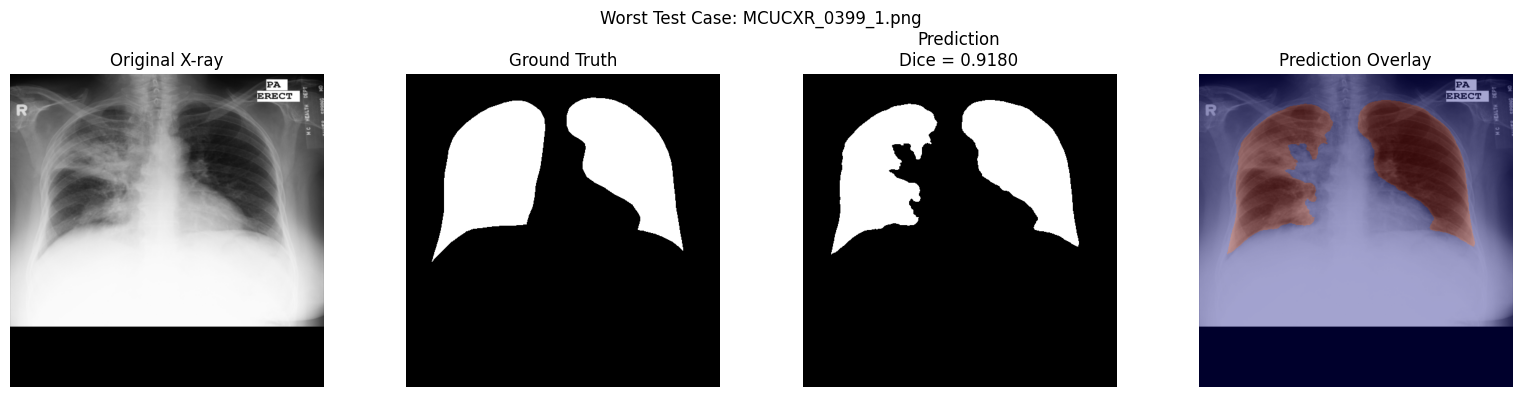

In [ ]:
# =========================
# Visualize Worst Test Case
# =========================

worst_filename = worst_case["filename"]

# Find its position inside the test dataset
worst_position = None

for i in range(len(test_dataset)):
    dataset_index = test_dataset.indices[i]

    if dataset.images[dataset_index].name == worst_filename:
        worst_position = i
        break

# Load the image and ground truth
image, mask = test_dataset[worst_position]

# Prediction
model.eval()

with torch.no_grad():

    input_image = image.unsqueeze(0).to(device)

    logits = model(input_image)

    probability = torch.sigmoid(logits)

    predicted_mask = (
        probability > 0.5
    ).float()

# Convert to NumPy
image_np = (
    image.permute(1, 2, 0)
    .cpu()
    .numpy()
)

ground_truth_np = (
    mask.squeeze(0)
    .cpu()
    .numpy()
)

prediction_np = (
    predicted_mask.squeeze()
    .cpu()
    .numpy()
)

# =========================
# Plot
# =========================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

# Original
axes[0].imshow(image_np, cmap="gray")
axes[0].set_title("Original X-ray")
axes[0].axis("off")

# Ground truth
axes[1].imshow(
    ground_truth_np,
    cmap="gray"
)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

# Prediction
axes[2].imshow(
    prediction_np,
    cmap="gray"
)
axes[2].set_title(
    f"Prediction\nDice = {worst_case['dice']:.4f}"
)
axes[2].axis("off")

# Overlay
axes[3].imshow(
    image_np,
    cmap="gray"
)

axes[3].imshow(
    prediction_np,
    alpha=0.35,
    cmap="jet"
)

axes[3].set_title("Prediction Overlay")
axes[3].axis("off")

plt.suptitle(
    f"Worst Test Case: {worst_filename}"
)

plt.tight_layout()
plt.show()

Save Final Evaluation Results to Google Drive

In [ ]:
# =========================
# Save Final Evaluation
# =========================

import json

FINAL_RESULTS_PATH = RESULTS_DIR / "final_test_results.json"

final_results = {
    "model": "U-Net",
    "input_size": "512x512",
    "batch_size": BATCH_SIZE,
    "best_epoch": int(checkpoint["epoch"]),
    "best_validation_loss": float(checkpoint["val_loss"]),
    "test_samples": len(test_dataset),
    "mean_dice": float(mean_dice),
    "mean_iou": float(mean_iou),
    "best_test_case": {
        "filename": best_case["filename"],
        "dice": float(best_case["dice"]),
        "iou": float(best_case["iou"])
    },
    "worst_test_case": {
        "filename": worst_case["filename"],
        "dice": float(worst_case["dice"]),
        "iou": float(worst_case["iou"])
    },
    "per_image_results": per_image_results
}

with open(FINAL_RESULTS_PATH, "w") as f:
    json.dump(
        final_results,
        f,
        indent=4
    )

print("Final evaluation saved successfully!")
print()
print("Results file:")
print(FINAL_RESULTS_PATH)

print("\nFinal metrics:")
print(f"Mean Dice : {mean_dice:.4f}")
print(f"Mean IoU  : {mean_iou:.4f}")

Final evaluation saved successfully!

Results file:
/content/drive/MyDrive/LungSegmentation/results/final_test_results.json

Final metrics:
Mean Dice : 0.9758
Mean IoU  : 0.9532


Save Test Predictions and Visualizations

In [ ]:
# =========================
# Save Test Predictions
# =========================

PREDICTIONS_DIR = RESULTS_DIR / "test_predictions"
VISUALIZATIONS_DIR = RESULTS_DIR / "test_visualizations"

PREDICTIONS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VISUALIZATIONS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model.eval()

with torch.no_grad():

    for i in range(len(test_dataset)):

        # -------------------------
        # Load test sample
        # -------------------------
        image, mask = test_dataset[i]

        input_image = image.unsqueeze(0).to(device)

        # -------------------------
        # Prediction
        # -------------------------
        logits = model(input_image)

        probability = torch.sigmoid(logits)

        predicted_mask = (
            probability > 0.5
        ).float()

        # -------------------------
        # Convert to NumPy
        # -------------------------
        image_np = (
            image.permute(1, 2, 0)
            .cpu()
            .numpy()
        )

        ground_truth_np = (
            mask.squeeze(0)
            .cpu()
            .numpy()
        )

        prediction_np = (
            predicted_mask.squeeze()
            .cpu()
            .numpy()
        )

        # -------------------------
        # Filename
        # -------------------------
        dataset_index = test_dataset.indices[i]
        filename = dataset.images[dataset_index].name
        stem = Path(filename).stem

        # -------------------------
        # Save binary prediction
        # -------------------------
        prediction_image = Image.fromarray(
            (prediction_np * 255).astype(np.uint8)
        )

        prediction_image.save(
            PREDICTIONS_DIR / f"{stem}_prediction.png"
        )

        # -------------------------
        # Calculate metrics
        # -------------------------
        dice = calculate_dice(
            logits,
            mask.unsqueeze(0).to(device)
        )

        iou = calculate_iou(
            logits,
            mask.unsqueeze(0).to(device)
        )

        # -------------------------
        # Create visualization
        # -------------------------
        fig, axes = plt.subplots(
            1,
            4,
            figsize=(16, 4)
        )

        axes[0].imshow(
            image_np,
            cmap="gray"
        )
        axes[0].set_title("Original X-ray")
        axes[0].axis("off")

        axes[1].imshow(
            ground_truth_np,
            cmap="gray"
        )
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        axes[2].imshow(
            prediction_np,
            cmap="gray"
        )
        axes[2].set_title(
            f"Prediction\nDice={dice:.4f}"
        )
        axes[2].axis("off")

        axes[3].imshow(
            image_np,
            cmap="gray"
        )

        axes[3].imshow(
            prediction_np,
            alpha=0.35,
            cmap="jet"
        )

        axes[3].set_title(
            f"Overlay\nIoU={iou:.4f}"
        )
        axes[3].axis("off")

        plt.suptitle(filename)
        plt.tight_layout()

        # Save visualization
        plt.savefig(
            VISUALIZATIONS_DIR / f"{stem}_visualization.png",
            dpi=150,
            bbox_inches="tight"
        )

        plt.close(fig)


print("All test predictions saved successfully!")

print("\nPrediction masks:")
print(PREDICTIONS_DIR)

print("\nVisualization images:")
print(VISUALIZATIONS_DIR)

print("\nNumber of predictions:", len(list(
    PREDICTIONS_DIR.glob("*_prediction.png")
)))

print("Number of visualizations:", len(list(
    VISUALIZATIONS_DIR.glob("*_visualization.png")
)))

All test predictions saved successfully!

Prediction masks:
/content/drive/MyDrive/LungSegmentation/results/test_predictions

Visualization images:
/content/drive/MyDrive/LungSegmentation/results/test_visualizations

Number of predictions: 15
Number of visualizations: 15
